In [1]:
!pip install SimpleITK scikit-image tqdm


[notice] A new release of pip is available: 24.2 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
import os
import random
import numpy as np
import SimpleITK as sitk
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from tqdm import tqdm
import matplotlib.pyplot as plt

In [3]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cpu


In [4]:
DATA_ROOT = "/synthRAD2025_Task2_Train/synthRAD2025_Task2_Train/Task2"

In [5]:
def build_dataset(root):
    data = []
    regions = ["HN"]

    for r in regions:
        path = os.path.join(root, r)
        for p in os.listdir(path):
            pp = os.path.join(path, p)
            data.append({
                "cbct": os.path.join(pp, "cbct.mha"),
                "ct": os.path.join(pp, "ct.mha"),
                "mask": os.path.join(pp, "mask.mha")
            })

    return data

dataset_index = build_dataset(DATA_ROOT)
dataset_index = dataset_index[:60]

print("Samples:", len(dataset_index))

Samples: 60


In [6]:
def load_mha(path):
    return sitk.GetArrayFromImage(sitk.ReadImage(path))

In [7]:
def preprocess(cbct, ct, mask):
    cbct = np.clip(cbct, -1024, 2000)
    ct   = np.clip(ct, -1024, 2000)

    cbct = (cbct + 1024) / 3024
    ct   = (ct + 1024) / 3024

    cbct = cbct * 2 - 1
    ct   = ct * 2 - 1

    mask = (mask > 0).astype(np.float32)

    return cbct, ct, mask

In [8]:
def extract_patch(cbct, ct, mask, size=(48,48,48)):
    z,y,x = cbct.shape
    dz,dy,dx = size

    valid = np.argwhere(mask > 0)

    if len(valid) > 0 and random.random() < 0.8:
        cz,cy,cx = valid[random.randint(0, len(valid)-1)]
        z0 = max(0, min(cz - dz//2, z-dz))
        y0 = max(0, min(cy - dy//2, y-dy))
        x0 = max(0, min(cx - dx//2, x-dx))
    else:
        z0 = random.randint(0, z-dz)
        y0 = random.randint(0, y-dy)
        x0 = random.randint(0, x-dx)

    return (
        cbct[z0:z0+dz, y0:y0+dy, x0:x0+dx],
        ct[z0:z0+dz, y0:y0+dy, x0:x0+dx],
        mask[z0:z0+dz, y0:y0+dy, x0:x0+dx]
    )

In [9]:
class SynthDataset(Dataset):
    def __init__(self, index, cache_size=20):
        self.paths = index
        self.cache = {}
        self.cache_size = cache_size

    def load_case(self, i):
        s = self.paths[i]
        cbct = load_mha(s["cbct"])
        ct   = load_mha(s["ct"])
        mask = load_mha(s["mask"])
        return preprocess(cbct, ct, mask)

    def __getitem__(self, i):

        # 🔹 caching (same as before)
        if i not in self.cache:
            if len(self.cache) >= self.cache_size:
                self.cache.pop(next(iter(self.cache)))
            self.cache[i] = self.load_case(i)

        cbct, ct, mask = self.cache[i]

        # 🔥 KEY FIX: sample ONE random patch PER CALL
        cbct_p, ct_p, mask_p = extract_patch(cbct, ct, mask)

        return (
            torch.tensor(cbct_p).unsqueeze(0).float(),
            torch.tensor(ct_p).unsqueeze(0).float(),
            torch.tensor(mask_p).unsqueeze(0).float()
        )

    def __len__(self):
        return len(self.paths)

In [10]:
random.shuffle(dataset_index)

split = int(0.8 * len(dataset_index))

train_ds = SynthDataset(dataset_index[:split])
val_ds   = SynthDataset(dataset_index[split:])

train_loader = DataLoader(train_ds, batch_size=1, shuffle=True, num_workers=0, pin_memory=True)
val_loader   = DataLoader(val_ds, batch_size=1, shuffle=False, num_workers=0, pin_memory=True)

print(len(train_ds), len(val_ds))

48 12


In [11]:
class DoubleConv(nn.Module):
    def __init__(self, i,o):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv3d(i,o,3,1,1),
            nn.InstanceNorm3d(o),
            nn.ReLU(),
            nn.Conv3d(o,o,3,1,1),
            nn.InstanceNorm3d(o),
            nn.ReLU()
        )
    def forward(self,x): return self.net(x)

def crop(enc, dec):
    _,_,D,H,W = dec.shape
    return enc[:, :, :D, :H, :W]

class UNet3D(nn.Module):
    def __init__(self):
        super().__init__()
        self.e1 = DoubleConv(2,32)
        self.e2 = DoubleConv(32,64)
        self.e3 = DoubleConv(64,128)

        self.pool = nn.MaxPool3d(2)
        self.b = DoubleConv(128,256)

        self.u3 = nn.ConvTranspose3d(256,128,2,2)
        self.d3 = DoubleConv(256,128)

        self.u2 = nn.ConvTranspose3d(128,64,2,2)
        self.d2 = DoubleConv(128,64)

        self.u1 = nn.ConvTranspose3d(64,32,2,2)
        self.d1 = DoubleConv(64,32)

        self.out = nn.Conv3d(32,1,1)

    def forward(self,x):
        inp = x[:,0:1]

        e1 = self.e1(x)
        e2 = self.e2(self.pool(e1))
        e3 = self.e3(self.pool(e2))

        b = self.b(self.pool(e3))

        u3 = self.u3(b)
        d3 = self.d3(torch.cat([u3, crop(e3,u3)],1))

        u2 = self.u2(d3)
        d2 = self.d2(torch.cat([u2, crop(e2,u2)],1))

        u1 = self.u1(d2)
        d1 = self.d1(torch.cat([u1, crop(e1,u1)],1))

        return inp + self.out(d1)   

In [12]:
class CharbonnierLoss(nn.Module):
    def __init__(self, eps=1e-3):
        super().__init__()
        self.eps = eps

    def forward(self, x, y):
        return torch.mean(torch.sqrt((x-y)**2 + self.eps**2))

def ssim3d(x,y):
    mu_x = F.avg_pool3d(x,3,1,1)
    mu_y = F.avg_pool3d(y,3,1,1)
    return torch.mean((2*mu_x*mu_y+1e-4)/(mu_x**2+mu_y**2+1e-4))

def edge_loss(x,y):
    dx = x[:,:,:,:,1:] - x[:,:,:,:,:-1]
    dy = x[:,:,:,1:,:] - x[:,:,:,:-1,:]
    dz = x[:,:,1:,:,:] - x[:,:,:-1,:,:]

    tx = y[:,:,:,:,1:] - y[:,:,:,:,:-1]
    ty = y[:,:,:,1:,:] - y[:,:,:,:-1,:]
    tz = y[:,:,1:,:,:] - y[:,:,:-1,:,:]

    return F.l1_loss(dx,tx)+F.l1_loss(dy,ty)+F.l1_loss(dz,tz)

charb = CharbonnierLoss()

def total_loss(pred, target, mask):

    
    l1 = F.l1_loss(pred * mask, target * mask)

    s  = 1 - ssim3d(pred, target)

    e  = edge_loss(pred, target)

    return 2.0*l1 + 0.2*s + 0.3*e

In [13]:
model = UNet3D().to(device)

opt = torch.optim.AdamW(model.parameters(), lr=1e-4)

scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(opt, T_max=15000)

scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))

print("Model ready (long training mode)")

Model ready (long training mode)


C:\Users\sajid\AppData\Local\Temp\ipykernel_2916\4279456336.py:7: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = torch.cuda.amp.GradScaler(enabled=(device.type=="cuda"))


In [14]:
def train_step(cbct, ct, mask):
    cbct, ct, mask = cbct.to(device), ct.to(device), mask.to(device)

    x = torch.cat([cbct, mask],1)

    with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):
        pred = model(x)
        loss = total_loss(pred, ct, mask)

    opt.zero_grad()
    scaler.scale(loss).backward()
    scaler.step(opt)
    scaler.update()

    scheduler.step()  

    return loss.item()

In [15]:
TOTAL_STEPS = 15000
LOG = 100

model.train()

for step in range(TOTAL_STEPS):

    idx = random.randint(0, len(train_ds)-1)
    cbct, ct, mask = train_ds[idx]

    cbct = cbct.unsqueeze(0).to(device)
    ct   = ct.unsqueeze(0).to(device)
    mask = mask.unsqueeze(0).to(device)

    loss = train_step(cbct, ct, mask)

    if step % LOG == 0:
        print(f"Step {step} Loss: {loss:.4f}")

C:\Users\sajid\AppData\Local\Temp\ipykernel_2916\95030281.py:6: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with torch.cuda.amp.autocast(enabled=(device.type=="cuda")):


Step 0 Loss: 0.6711
Step 100 Loss: 0.2996
Step 200 Loss: 0.3128
Step 300 Loss: 0.4391
Step 400 Loss: 0.0910
Step 500 Loss: 0.2327
Step 600 Loss: 0.2323
Step 700 Loss: 0.2549
Step 800 Loss: 0.1415
Step 900 Loss: 0.4093
Step 1000 Loss: 0.0727
Step 1100 Loss: 0.3238
Step 1200 Loss: 0.2077
Step 1300 Loss: 0.2555
Step 1400 Loss: 0.4251
Step 1500 Loss: 0.1844
Step 1600 Loss: 0.3290
Step 1700 Loss: 0.1783
Step 1800 Loss: 0.1787
Step 1900 Loss: 0.0463
Step 2000 Loss: 0.1318
Step 2100 Loss: 0.2330
Step 2200 Loss: 0.1483
Step 2300 Loss: 0.0987
Step 2400 Loss: 0.1446
Step 2500 Loss: 0.3388
Step 2600 Loss: 0.3578
Step 2700 Loss: 0.2960
Step 2800 Loss: 0.1581
Step 2900 Loss: 0.1365
Step 3000 Loss: 0.1364
Step 3100 Loss: 0.1302
Step 3200 Loss: 0.2220
Step 3300 Loss: 0.1217
Step 3400 Loss: 0.1489
Step 3500 Loss: 0.1042
Step 3600 Loss: 0.2393
Step 3700 Loss: 0.1308
Step 3800 Loss: 0.1902
Step 3900 Loss: 0.2148
Step 4000 Loss: 0.1381
Step 4100 Loss: 0.2838
Step 4200 Loss: 0.1211
Step 4300 Loss: 0.1797


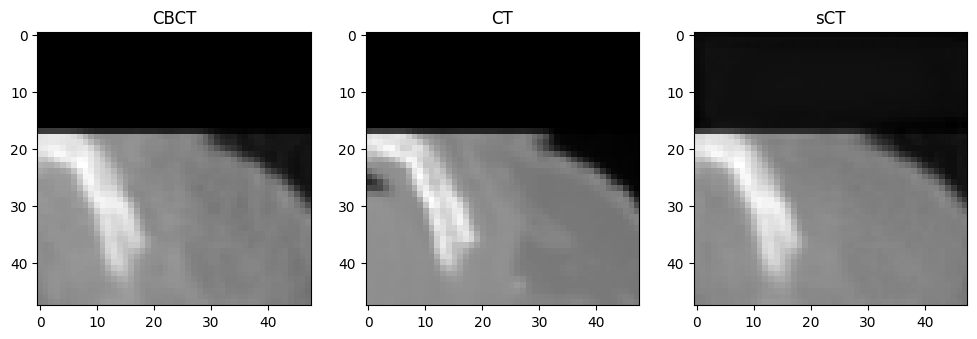

In [18]:
cbct, ct, mask = next(iter(val_loader))

with torch.no_grad():
    pred = model(torch.cat([cbct.to(device), mask.to(device)],1))

cbct = cbct.numpy()[0,0]
ct   = ct.numpy()[0,0]
pred = pred.cpu().numpy()[0,0]

s = cbct.shape[0]//2

plt.figure(figsize=(12,4))
plt.subplot(1,3,1); plt.imshow(cbct[s],cmap='gray'); plt.title("CBCT")
plt.subplot(1,3,2); plt.imshow(ct[s],cmap='gray'); plt.title("CT")
plt.subplot(1,3,3); plt.imshow(pred[s],cmap='gray'); plt.title("sCT")
plt.show()

In [19]:
import numpy as np
from skimage.metrics import structural_similarity as ssim

def compute_metrics(pred, gt, mask=None):
    pred = pred.flatten()
    gt   = gt.flatten()

    if mask is not None:
        mask = mask.flatten() > 0
        pred = pred[mask]
        gt   = gt[mask]

    mae = np.mean(np.abs(pred - gt))
    mse = np.mean((pred - gt)**2)

    psnr = 20 * np.log10(2.0 / np.sqrt(mse + 1e-8))  # range [-1,1]

    return mae, mse, psnr


def compute_ssim_3d(pred, gt):
    scores = []
    for i in range(pred.shape[0]):  # slice-wise
        scores.append(
            ssim(
                pred[i],
                gt[i],
                data_range=2.0
            )
        )
    return np.mean(scores)

In [26]:
model.eval()

mae_list = []
mse_list = []
psnr_list = []
ssim_list = []

with torch.no_grad():
    for i, (cbct, ct, mask) in enumerate(val_loader):
        
        cbct = cbct.to(device)
        mask = mask.to(device)

        pred = model(torch.cat([cbct, mask],1))

        pred = pred.cpu().numpy()[0,0]
        gt   = ct.numpy()[0,0]
        m    = mask.cpu().numpy()[0,0]

        mae, mse, psnr = compute_metrics(pred, gt, m)
        ssim_val = compute_ssim_3d(pred, gt)

        mae_list.append(mae)
        mse_list.append(mse)
        psnr_list.append(psnr)
        ssim_list.append(ssim_val)

print("===== FINAL METRICS =====")
print(f"MAE:  {np.mean(mae_list):.4f}")
print(f"MSE:  {np.mean(mse_list):.4f}")
print(f"PSNR: {np.mean(psnr_list):.2f}")
print(f"SSIM: {np.mean(ssim_list):.4f}")

===== FINAL METRICS =====
MAE:  0.0845
MSE:  0.0174
PSNR: 24.48
SSIM: 0.8393
